In [1]:
!pip install timm

In [2]:
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms
from torchvision import datasets
from torch import optim
import torch.nn as nn
import numpy as np
import torch
import timm
import os

KeyboardInterrupt: 

In [1]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

NameError: name 'torch' is not defined

In [2]:
number_of_db_classes = 10

In [ ]:
####################################################
# MobileNetV2
class MobileNetV2(nn.Module):
    def __init__(self, class_num=1000, pretrained=False):
        super(MobileNetV2, self).__init__()
        self.class_num = class_num
        self.pretrained = pretrained

        # load model #####################################
        self.model = torch.hub.load('pytorch/vision:v0.10.0',
                                    'mobilenet_v2',
                                    pretrained=self.pretrained)

        # set last layer ################################
        if self.model.classifier[1].out_features != self.class_num:
            self.model.classifier[1] = nn.Linear(1280, self.class_num)
        self.model = self.model.to(device)

        # # Normal initialization #########################
        # for params, a in self.model.named_parameters():
        #     torch.nn.init.normal(a.data)

    def forward(self, x):
        out = self.model(x)
        return out

In [ ]:
# Define a Network
model = MobileNetV2(class_num=number_of_db_classes, pretrained=True)

In [ ]:
# Transformer

def cifar10_transformer():
    transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    return transform_train, transform_test

In [ ]:
batch_size = 256
train_kwargs = {'batch_size': batch_size}
cifar10_transformer_train, cifar10_transformer_test = cifar10_transformer()
train_loader = torch.utils.data.DataLoader(datasets.CIFAR10('data',
                                                                 train=True,
                                                                 download=True,
                                                                 transform=cifar10_transformer_train), **train_kwargs)

test_kwargs = {'batch_size': batch_size}
#test_kwargs.update(cuda_kwargs)
test_loader = torch.utils.data.DataLoader(datasets.CIFAR10('data', train=False, transform=cifar10_transformer_test), **test_kwargs)

Train Hyperparameters

In [ ]:
lr = 1
optimizer = optim.Adadelta(model.parameters(), lr=lr)
best_auc = 0
scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

Loss Function

In [ ]:
# Loss Function ##################################
loss_function = nn.CrossEntropyLoss()

Training Function

In [ ]:
from tqdm import tqdm

def train_step(epoch, loss_train_epoch):
    model.train()
    epoch_loss = []
    loop = tqdm(enumerate(train_loader))
    loop.set_description(f"Epoch {epoch}")
    for batch_idx, (data, target) in loop:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        epoch_loss.append(loss.item())
        loss.backward()
        optimizer.step()
        loop.set_postfix({'Iter': '[{}/{}]'.format(batch_idx * len(data), len(train_loader.dataset)),
                          'Epoch_Loss': sum(epoch_loss)/len(epoch_loss),
                          'Batch_Loss': loss.item()
                           })
    loss_train_epoch.append(sum(epoch_loss)/len(epoch_loss))
    return loss_train_epoch

Testing Function

In [ ]:
def test(best_auc, loss_test_epoch, epoch_auc_history):
    model.eval()
    test_loss_list = []
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss_list.append(loss_function(output, target).item())
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss = sum(test_loss_list)/len(test_loss_list)
    loss_test_epoch.append(test_loss)
    epoch_auc_history.append(correct / 100)
    if correct > best_auc:
        best_auc = correct
        torch.save(model.state_dict(), 'best.pth')

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    print('Best Accuracy :', best_auc)
    return best_auc, loss_test_epoch, epoch_auc_history

Training

In [ ]:
epoches = 25
loss_train_epoch = []
epoch_auc_history = []
loss_test_epoch = []
best_auc = 0
for epoch in range(1, epoches):
    loss_train_epoch = train_step(epoch, loss_train_epoch)
    best_auc, loss_test_epoch, epoch_auc_history = test(best_auc, loss_test_epoch, epoch_auc_history)
    scheduler.step()

NameError: name 'epoch_auc_history' is not defined

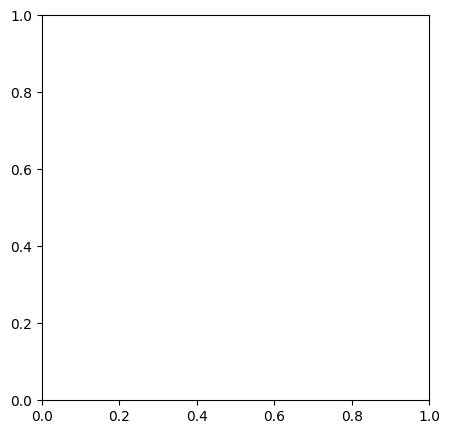

In [3]:
import matplotlib.pyplot as plt
fig, plt_2 = plt.subplots(1, 1, figsize=(5, 5))
plt_2.plot(epoch_auc_history, color='red')
plt_2.set_ylabel('Accuracy')
plt_2.set_xlabel('Epoch')
plt_2.set_title('Dataset: {Dataset} - Backbone: {Backbone}'.format(Dataset='Cifar10', Backbone='ResNet18'))
fig.show()


In [ ]:
fig, plt_2 = plt.subplots(1, 1, figsize=(5, 5))
plt_2.plot(loss_train_epoch, color='red', label='Train')
plt_2.plot(loss_test_epoch, color='blue', label='Test')
plt_2.set_ylabel('Loss')
plt_2.set_xlabel('Epoch')
plt_2.set_title('Dataset: {Dataset} - Backbone: {Backbone}'.format(Dataset='Cifar10', Backbone='ResNet50'))
fig.show()